Problem 1

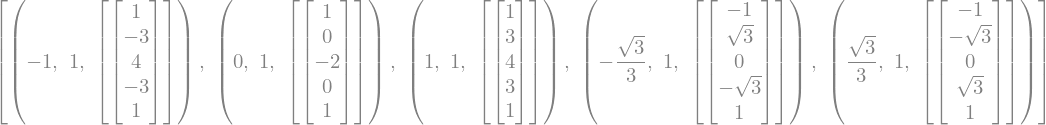

In [1]:
import sympy as sp
p = sp.Matrix([
    [0, 1, 0, 0, 0],
    [sp.Rational(1,3), 0, sp.Rational(2,3), 0, 0],
    [0, sp.Rational(1,2), 0, sp.Rational(1,2), 0],
    [0, 0, sp.Rational(2,3), 0, sp.Rational(1,3)],
    [0, 0, 0, 1, 0]
])

sp.init_printing()
(p.T).eigenvects()

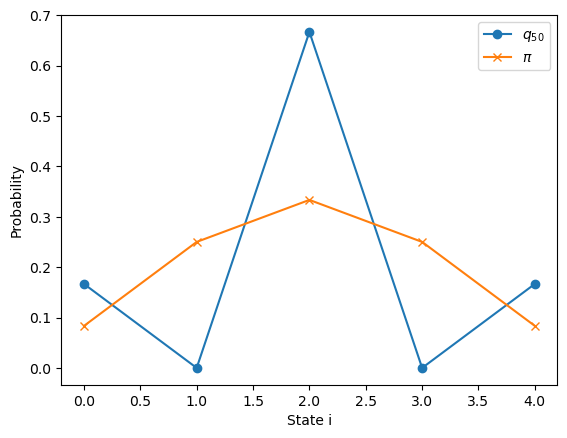

In [14]:
import numpy as np
import matplotlib.pyplot as plt


p = np.array([
    [0, 1, 0, 0, 0],
    [1/3, 0, 2/3, 0, 0],
    [0, 1/2, 0, 1/2, 0],
    [0, 0, 2/3, 0, 1/3],
    [0, 0, 0, 1, 0]
], dtype=float)

q0 = np.zeros(5)
q0[2] = 1

# Compute q50
p50 = np.linalg.matrix_power(p, 50)
q50 = q0 @ p50

# Plot
i = np.arange(5)
pi = np.array([1,3,4,3,1], dtype=float)
pi /= np.sum(abs(pi))

plt.figure()
plt.plot(i, q50, marker='o', label=r'$q_{50}$')
plt.plot(i, pi, marker='x', label=r'$\pi$')
plt.xlabel('State i')
plt.ylabel('Probability')
plt.legend()
plt.show()

Because we are making an even number of time steps, it is impossible for the Markov chain to be in either state 1 or 3. So $q_{50}$ will not look like $\pi$. If we do an odd number of time steps, then state 0, 2, and 4 are impossible so $q$ will still not look like $\pi$. This is because the periodicity of the Markov chain.

Problem 3

In [18]:
def g(t):
    return np.exp(2*(t-1))-t

def bisect(g, a, b, N=1000):
    ga = g(a)
    gb = g(b)
    for i in range(N):
        c = (a + b) / 2
        gc = g(c)

        if ga*gc < 0:
            b = c
            gb = gc
        else:
            a = c
            ga = gc

    return (a + b) / 2

print(bisect(g, 0, .99))

0.20318786997998006


Problem 4

In [24]:
def simulate_avalanche(a, max_gen=200):
    X = 1 

    for _ in range(max_gen):
        if X == 0:
            return True

        Z = np.random.binomial(X, 1 - a)
        X = 2 * Z

    return X == 0 


def estimate_extinction_prob(a, trials=1000):
    extinct_count = 0
    for _ in range(trials):
        if simulate_avalanche(a):
            extinct_count += 1

    return extinct_count / trials


a = 0.49
prob_sim = estimate_extinction_prob(a, trials=1000)

print("Simulated extinction probability:", prob_sim)

q_theory = a / (1 - a)
print("Theoretical extinction probability:", q_theory)

Simulated extinction probability: 0.954
Theoretical extinction probability: 0.9607843137254901


These two probabilities are basically identical, which means the calculation from part (a) is most likely correct.

Problem 6

In [30]:
def simulate_avalanche():
    X = 1         
    total = 1 

    while X > 0:
        Z = np.random.binomial(X, 0.5)
        X = 2 * Z
        total += X

    return total


def estimate(trials=1000):
    count = 0

    for _ in range(trials):
        S = simulate_avalanche()
        if S == 3:
            count += 1

    return count / trials


prob_sim = estimate(1000)
print("Simulated P(S=3):", prob_sim)

import math
k=2
prob_theory = math.factorial(2*k-2) / (2**(2*k-1) * math.factorial(k) * math.factorial(k-1))
print("Theoretical P(S=3):", prob_theory)

Simulated P(S=3): 0.131
Theoretical P(S=3): 0.125


These two probabilities are basically identical, which means the calculation from part (b) is most likely correct.